In [1]:
# =========================================================
# TELECOM CUSTOMER CHURN PREDICTION - EDA
# =========================================================

# Import Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Set plot style
sns.set(style='whitegrid')

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
# =========================================================
# LOAD DATASET
# =========================================================

df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [3]:
# =========================================================
# CONVERT TOTALCHARGES TO NUMERIC
# =========================================================

df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

df['TotalCharges'].dtype

dtype('float64')

In [4]:
# =========================================================
# HANDLE MISSING VALUES
# =========================================================

df['TotalCharges'].fillna(
    df['TotalCharges'].median(),
    inplace=True
)

df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

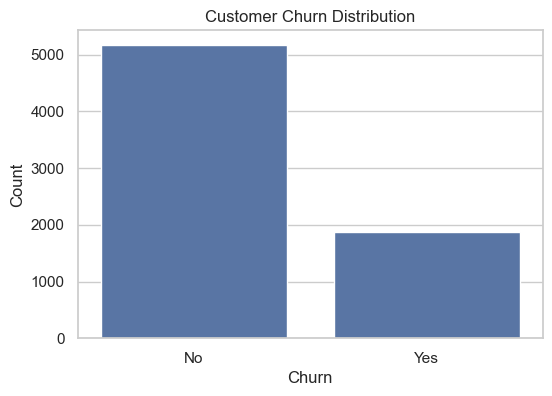

In [5]:
# =========================================================
# CHURN DISTRIBUTION
# =========================================================

plt.figure(figsize=(6,4))

sns.countplot(x='Churn', data=df)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")

plt.show()

In [6]:
# =========================================================
# CHURN PERCENTAGE
# =========================================================

churn_percent = df['Churn'].value_counts(normalize=True) * 100

print(churn_percent)

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


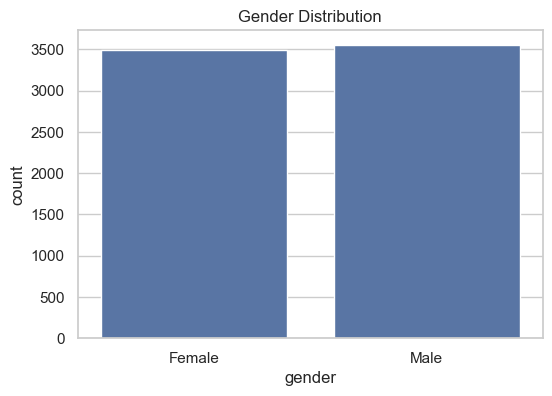

In [7]:
# =========================================================
# GENDER DISTRIBUTION
# =========================================================

plt.figure(figsize=(6,4))

sns.countplot(x='gender', data=df)

plt.title("Gender Distribution")

plt.show()

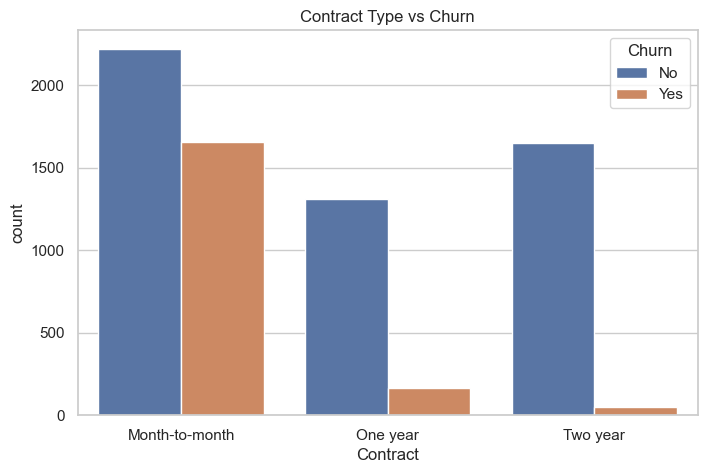

In [8]:
# =========================================================
# CONTRACT TYPE VS CHURN
# =========================================================

plt.figure(figsize=(8,5))

sns.countplot(
    x='Contract',
    hue='Churn',
    data=df
)

plt.title("Contract Type vs Churn")

plt.show()

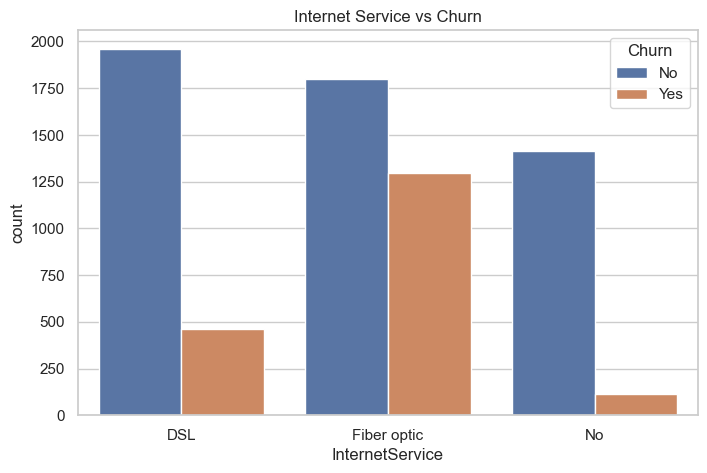

In [9]:
# =========================================================
# INTERNET SERVICE VS CHURN
# =========================================================

plt.figure(figsize=(8,5))

sns.countplot(
    x='InternetService',
    hue='Churn',
    data=df
)

plt.title("Internet Service vs Churn")

plt.show()

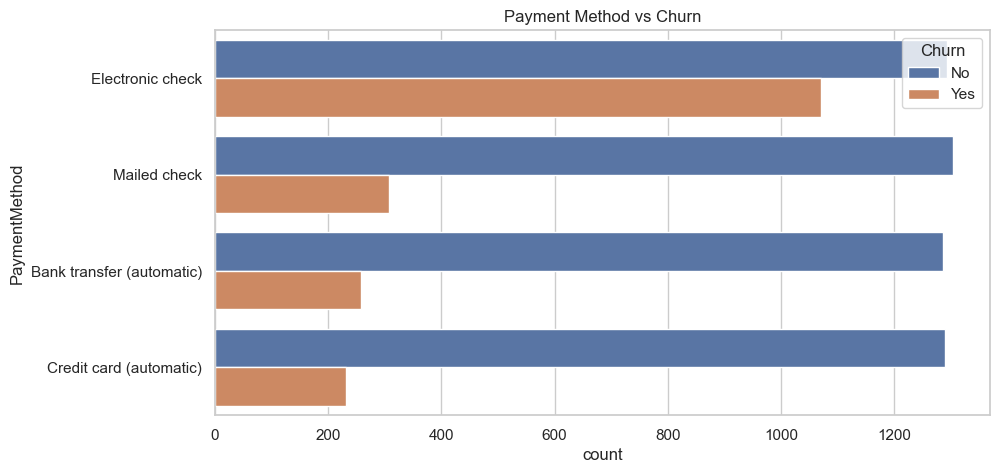

In [10]:
# =========================================================
# PAYMENT METHOD VS CHURN
# =========================================================

plt.figure(figsize=(10,5))

sns.countplot(
    y='PaymentMethod',
    hue='Churn',
    data=df
)

plt.title("Payment Method vs Churn")

plt.show()

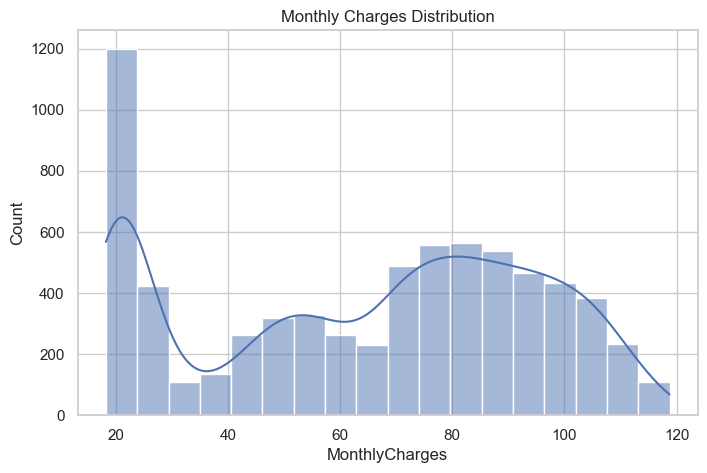

In [11]:
# =========================================================
# MONTHLY CHARGES DISTRIBUTION
# =========================================================

plt.figure(figsize=(8,5))

sns.histplot(
    df['MonthlyCharges'],
    kde=True
)

plt.title("Monthly Charges Distribution")

plt.show()

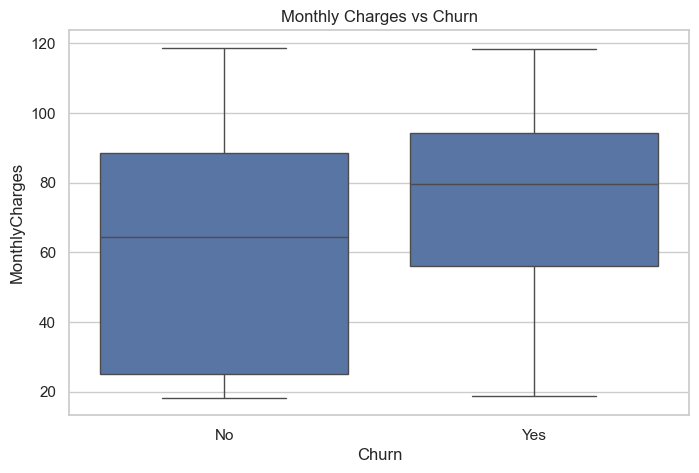

In [12]:
# =========================================================
# MONTHLY CHARGES VS CHURN
# =========================================================

plt.figure(figsize=(8,5))

sns.boxplot(
    x='Churn',
    y='MonthlyCharges',
    data=df
)

plt.title("Monthly Charges vs Churn")

plt.show()

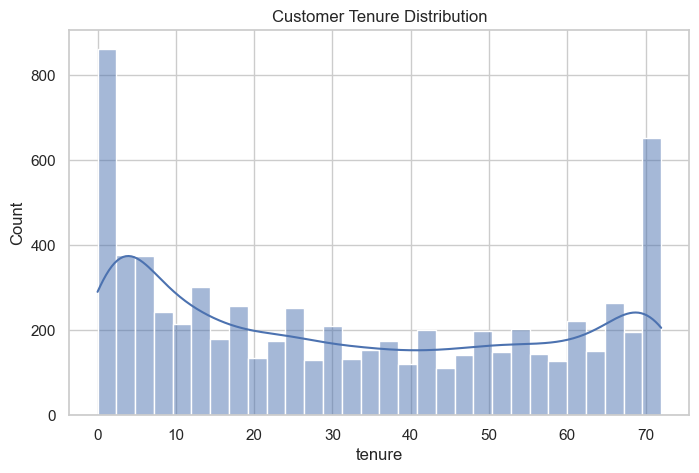

In [13]:
# =========================================================
# TENURE DISTRIBUTION
# =========================================================

plt.figure(figsize=(8,5))

sns.histplot(
    df['tenure'],
    bins=30,
    kde=True
)

plt.title("Customer Tenure Distribution")

plt.show()

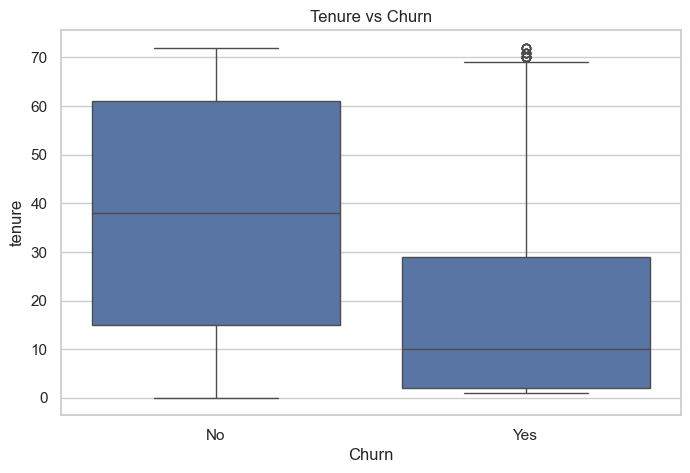

In [14]:
# =========================================================
# TENURE VS CHURN
# =========================================================

plt.figure(figsize=(8,5))

sns.boxplot(
    x='Churn',
    y='tenure',
    data=df
)

plt.title("Tenure vs Churn")

plt.show()

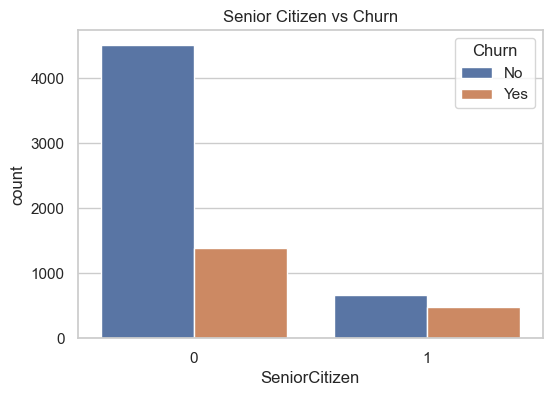

In [15]:
# =========================================================
# SENIOR CITIZEN VS CHURN
# =========================================================

plt.figure(figsize=(6,4))

sns.countplot(
    x='SeniorCitizen',
    hue='Churn',
    data=df
)

plt.title("Senior Citizen vs Churn")

plt.show()

In [16]:
# =========================================================
# ENCODE CATEGORICAL VARIABLES
# =========================================================

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df_encoded = df.copy()

for col in df_encoded.columns:
    
    if df_encoded[col].dtype == 'object':
        
        df_encoded[col] = le.fit_transform(
            df_encoded[col]
        )

print("Encoding Completed")

Encoding Completed


In [18]:
# =========================================================
# KEY INSIGHTS
# =========================================================

print("""
KEY INSIGHTS FROM EDA:

1. Customers with month-to-month contracts have higher churn.

2. Customers with higher monthly charges tend to churn more.

3. Long tenure customers are less likely to churn.

4. Fiber optic internet users show relatively higher churn.

5. Electronic check payment users have high churn rates.

6. Senior citizens show slightly higher churn behavior.
""")


KEY INSIGHTS FROM EDA:

1. Customers with month-to-month contracts have higher churn.

2. Customers with higher monthly charges tend to churn more.

3. Long tenure customers are less likely to churn.

4. Fiber optic internet users show relatively higher churn.

5. Electronic check payment users have high churn rates.

6. Senior citizens show slightly higher churn behavior.

